# 01c · EDA: data quality

**Question.** How trustworthy are the rows and labels themselves?

Cleaning (`00_data_and_cleaning`) removed impossible values. This notebook looks at what cleaning
cannot fix: repeated flows, contradictory labels, and flows whose label does not match their
content.

In [1]:
import sys, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from sklearn.metrics import roc_auc_score
from src.evaluation.folds import day_key
from src.models.cross_dataset import FAMILY
from src.reporting.plots import style, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

df = pd.read_parquet("../data/processed/cicids2017_eval.parquet")
features = df.select_dtypes(include=[np.number]).columns.tolist()
df["day"] = df["Meta_source"].map(lambda s: day_key(s, "2017"))
df["family"] = df["Label"].map(FAMILY)
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
ATTACK_FAMILIES = ["Brute force (FTP/SSH)", "DoS", "Heartbleed", "Web attack", "Infiltration", "Bot", "PortScan", "DDoS"]
BLUES = LinearSegmentedColormap.from_list("blues", ["#f2f6fc", "#9ec5f4", "#3987e5", "#1c5cab", "#0d366b"])
BENIGN_C, ATTACK_C = "#2a78d6", "#eb6834"
print(f"CIC-IDS2017 evaluation copy: {len(df):,} flows, {len(features)} numeric features")

df["vector"] = pd.util.hash_pandas_object(df[features], index=False).to_numpy()
df["exact_duplicate"] = df.duplicated(subset=["vector", "Label"], keep="first")
labels_per_vector = df.groupby("vector")["Label"].transform("nunique")
conflicts = df[labels_per_vector > 1]
empty = (df["Total Length of Fwd Packets"] == 0) & (df["Total Length of Bwd Packets"] == 0)
df["empty"] = empty
web = df[df["family"] == "Web attack"]
print(f"Finding: {df['exact_duplicate'].mean():.1%} of flows repeat an earlier flow exactly (up to "
      f"{df.groupby('Label')['exact_duplicate'].mean().max():.0%} for some attacks); {conflicts['vector'].nunique():,} "
      f"distinct flows carry contradictory labels; and {web['empty'].mean():.0%} of web-attack flows carry no "
      f"payload at all, so most 'web attacks' in the labels are not attack traffic.")

CIC-IDS2017 evaluation copy: 2,827,726 flows, 71 numeric features


Finding: 10.9% of flows repeat an earlier flow exactly (up to 45% for some attacks); 697 distinct flows carry contradictory labels; and 91% of web-attack flows carry no payload at all, so most 'web attacks' in the labels are not attack traffic.


## Repeated flows and empty flows, by label

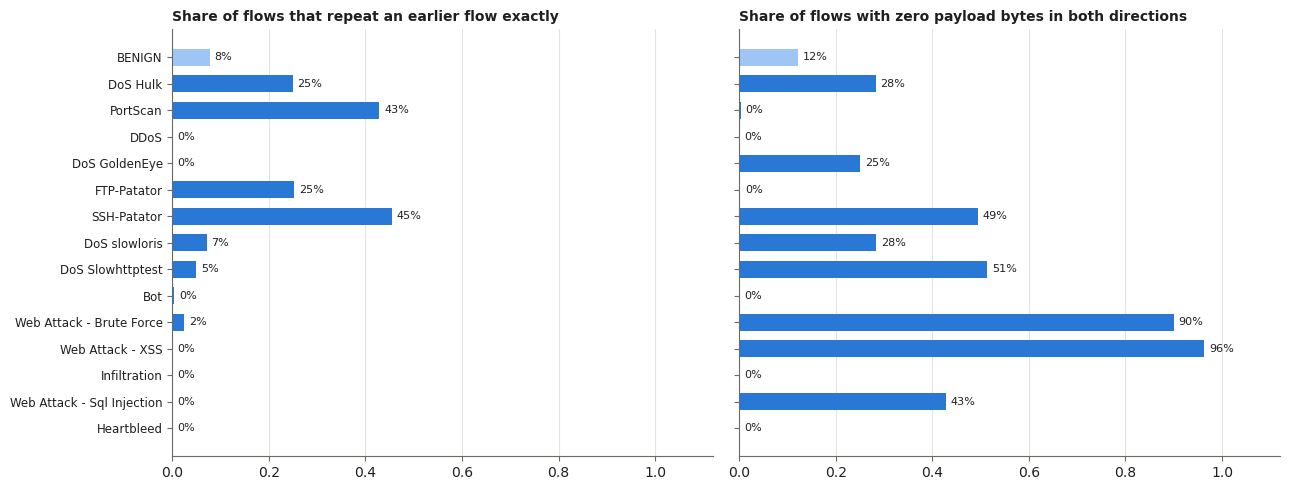

,flows,exact_duplicate,no_payload
Label,,,
BENIGN,2271170,0.078,0.123
DoS Hulk,230124,0.249,0.282
PortScan,158804,0.429,0.003
DDoS,128025,0.000,0.000
DoS GoldenEye,10293,0.001,0.251
FTP-Patator,7935,0.253,0.002
SSH-Patator,5897,0.454,0.495
DoS slowloris,5796,0.071,0.284
DoS Slowhttptest,5499,0.049,0.513


In [2]:
by_label = df.groupby("Label").agg(flows=("Label", "size"), exact_duplicate=("exact_duplicate", "mean"),
                                   no_payload=("empty", "mean")).sort_values("flows", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
order = by_label.index[::-1]
for ax, col, title in [(axes[0], "exact_duplicate", "Share of flows that repeat an earlier flow exactly"),
                       (axes[1], "no_payload", "Share of flows with zero payload bytes in both directions")]:
    ax.barh(order, by_label.loc[order, col], color=["#9ec5f4" if l == "BENIGN" else "#2a78d6" for l in order], height=0.65)
    for i, v in enumerate(by_label.loc[order, col]):
        ax.text(v + 0.01, i, f"{v:.0%}", va="center", fontsize=8, color=INK)
    ax.set_xlim(0, 1.12); ax.set_title(title, loc="left", fontsize=10, fontweight="bold", color=INK); style(ax)
axes[0].tick_params(axis="y", labelsize=8.5)
fig.tight_layout(); plt.show()
by_label.round(3)

## Contradictory labels

The same feature vector should not be both benign and an attack. Below, every distinct vector
that carries more than one label, grouped by the labels and whether the conflict is within one
day or across days.

In [3]:
pairs = conflicts.groupby("vector").agg(labels=("Label", lambda s: " vs ".join(sorted(set(s)))),
                                        days=("day", lambda s: " / ".join(sorted(set(s), key=DAYS.index))),
                                        rows=("Label", "size"))
pairs["same day"] = ~pairs["days"].str.contains("/")
pairs.groupby(["labels", "same day"]).agg(distinct_flows=("rows", "size"), rows=("rows", "sum")).sort_values("rows", ascending=False)

,,distinct_flows,rows
labels,same day,,
BENIGN vs DoS Hulk,False,95,4580
BENIGN vs PortScan,False,564,1618
BENIGN vs DoS Hulk,True,34,454
BENIGN vs DDoS,False,2,7
BENIGN vs DoS slowloris,False,1,5
BENIGN vs DDoS,True,1,2


In [4]:
# One example: the same feature vector, labelled benign on one day and PortScan on another
example = pairs[pairs["labels"] == "BENIGN vs PortScan"].index[0]
cols = ["day", "Label", "Destination Port", "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
        "Total Length of Fwd Packets", "SYN Flag Count", "RST Flag Count", "Init_Win_bytes_forward"]
conflicts.loc[conflicts["vector"] == example, cols].drop_duplicates(subset=["day", "Label"])

,day,Label,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,SYN Flag Count,RST Flag Count,Init_Win_bytes_forward
360730,Friday,PortScan,4848,54,1,1,2,0,0,1024
1282811,Thursday,BENIGN,4848,54,1,1,2,0,0,1024


## "Attacks" with no payload

An XSS or SQL injection attack has to send its payload. The table counts web-attack flows that
carry zero bytes in both directions and describes what they look like.

In [5]:
rows = []
for label in ["Web Attack - XSS", "Web Attack - Brute Force", "Web Attack - Sql Injection"]:
    w = df[df["Label"] == label]; e = w[w["empty"]]
    shape = e[["Total Fwd Packets", "Total Backward Packets"]].value_counts(normalize=True)
    rows.append({"label": label, "flows": len(w), "with payload": int((~w["empty"]).sum()),
                 "empty": len(e), "most common empty shape (fwd, bwd packets)": f"{shape.index[0]} in {shape.iloc[0]:.0%}",
                 "empty: median duration (s)": round(e["Flow Duration"].median() / 1e6, 1),
                 "empty: share with a FIN": round((e["FIN Flag Count"] > 0).mean(), 3),
                 "empty: server window 28,960": round((e["Init_Win_bytes_backward"] == 28960).mean(), 3),
                 "with payload: median forward bytes": w.loc[~w["empty"], "Total Length of Fwd Packets"].median()})
pd.DataFrame(rows).set_index("label").T

label,Web Attack - XSS,Web Attack - Brute Force,Web Attack - Sql Injection
flows,652,1507,21
with payload,24,151,12
empty,628,1356,9
"most common empty shape (fwd, bwd packets)","(3, 1) in 96%","(3, 1) in 89%","(1, 1) in 89%"
empty: median duration (s),5.4,5.5,0.0
empty: share with a FIN,0.0,0.0,0.0
"empty: server window 28,960",0.963,0.895,0.0
with payload: median forward bytes,48783.0,1022.0,568.0


## What this shows

- **Most web-attack rows are not attacks.** The large majority of XSS and web brute-force flows
  carry no payload. They share one shape (three packets one way, one back, a few seconds, no FIN,
  answered by the victim server's 28,960-byte window). Only a few dozen XSS flows carry the
  actual attack. This is consistent with the "TCP appendix" defect described by Engelen, Rimmer &
  Joosen (2021): packets left over after a connection is closed are split into a new flow that
  inherits the attack label. It also explains `03_forward_2017`: the detector that "caught" 82%
  of unseen web attacks was recognizing these empty server replies.
- **Some attacks are mostly repeats.** SSH-Patator and PortScan rows are nearly half exact
  duplicates. Recall on those classes counts the same flow many times.
- **Labels contradict each other, across days and within them.** Most conflicting distinct flows
  are benign on one day and PortScan on Friday: short probe-like flows (the example above is one
  packet each way, 54 microseconds) that are indistinguishable from benign traffic in these
  features. By row count, benign vs DoS Hulk dominates, including conflicts within Wednesday itself. Removing them before a split (as the first cleaning did) uses test
  labels; the evaluation copy keeps them.

## Known defects from the literature

Engelen, Rimmer & Joosen (2021, "Troubleshooting an Intrusion Detection Dataset: the CICIDS2017
Case Study") report flow-construction errors in the CICFlowMeter tool, labelling errors, and
attempted attacks labelled as attacks. Findings above that match their description are stated as
consistent with it, not as independent confirmation.

## Consequences for evaluation

- Per-family recall for web attacks mostly measures empty connections, not attacks.
- Duplicates inflate both the training signal and the test counts for some families.
- Any cleaning that uses labels must happen inside the training split, never before it.